# PT Sales Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

## 1) Load data

In [2]:
# Update the path if needed
file_path = "sales_analysis_202607251357.csv"

df = pd.read_csv(file_path)
df.head()

,Venda_ID,Data da Venda,Quantidade,Preço Unitário,Cliente_ID,customer_name,Género,Idade,Cidade,Produto_ID,product_name,Categoria,Cor,Tamanho,Preço,Custo_Aquisição,Loja_ID,store_name,Região,store_city,Tipo
0,1,2020-04-19 13:51:40,30,175.88,41,Lourenço Branco,M,24,Cascais,259,Harum,Roupas,Vermelho,S,53.82,34.55,1,Loja Borges S.A.,Centro,Leiria,Online
1,2,2016-05-16 04:52:08,90,83.19,308,Frederico Loureiro,M,62,Vila do Corvo,898,Eius,Calçado,Rosa,37,54.14,13.43,1,Loja Borges S.A.,Centro,Leiria,Online
2,3,2018-11-30 17:45:41,88,682.42,910,Ema Leal-Mota,F,31,Silves,357,Quasi,Roupas,Laranja,XS,75.15,43.01,3,Loja Araújo S/A,Alentejo,Ferreira do Alentejo,Física
3,4,2024-12-31 15:53:01,63,365.50,914,Gaspar Neto,M,44,Lisboa,490,Voluptatibus,Roupas,Branco,XL,30.51,29.78,1,Loja Borges S.A.,Centro,Leiria,Online
4,5,2019-03-21 17:00:00,47,182.52,92,Débora Silva,M,65,Faro,341,Suscipit,Roupas,Vermelho,XXL,84.84,26.49,4,Loja Maia Loureiro S.A.,Centro,Castelo Branco,Física


## 2) Data structure and consistency checks

In [3]:
# Basic structure
print("Shape:", df.shape)
display(df.head(10))
display(df.info())

Shape: (20000, 21)


,Venda_ID,Data da Venda,Quantidade,Preço Unitário,Cliente_ID,customer_name,Género,Idade,Cidade,Produto_ID,product_name,Categoria,Cor,Tamanho,Preço,Custo_Aquisição,Loja_ID,store_name,Região,store_city,Tipo
0,1,2020-04-19 13:51:40,30,175.88,41,Lourenço Branco,M,24,Cascais,259,Harum,Roupas,Vermelho,S,53.82,34.55,1,Loja Borges S.A.,Centro,Leiria,Online
1,2,2016-05-16 04:52:08,90,83.19,308,Frederico Loureiro,M,62,Vila do Corvo,898,Eius,Calçado,Rosa,37,54.14,13.43,1,Loja Borges S.A.,Centro,Leiria,Online
2,3,2018-11-30 17:45:41,88,682.42,910,Ema Leal-Mota,F,31,Silves,357,Quasi,Roupas,Laranja,XS,75.15,43.01,3,Loja Araújo S/A,Alentejo,Ferreira do Alentejo,Física
3,4,2024-12-31 15:53:01,63,365.50,914,Gaspar Neto,M,44,Lisboa,490,Voluptatibus,Roupas,Branco,XL,30.51,29.78,1,Loja Borges S.A.,Centro,Leiria,Online
4,5,2019-03-21 17:00:00,47,182.52,92,Débora Silva,M,65,Faro,341,Suscipit,Roupas,Vermelho,XXL,84.84,26.49,4,Loja Maia Loureiro S.A.,Centro,Castelo Branco,Física
5,6,2017-08-22 14:16:52,74,148.25,58,Filipa Carneiro,M,51,Vila do Porto,372,Sapiente,Calçado,Preto,45,29.70,14.45,1,Loja Borges S.A.,Centro,Leiria,Online
6,7,2017-10-30 01:15:12,62,841.36,143,Vera Gonçalves,F,49,Vila Real de Santo António,506,Quos,Calçado,Azul,43,26.47,41.21,5,Loja Araújo Pinto Lda.,Centro,Castelo de Paiva,Online
7,8,2018-06-05 18:07:10,62,340.15,903,Salvador Nogueira,M,18,Silves,833,Quia,Calçado,Verde,43,95.62,31.70,1,Loja Borges S.A.,Centro,Leiria,Online
8,9,2022-11-23 18:16:01,68,81.98,672,Clara Pereira,F,52,Amarante,560,Doloribus,Calçado,Branco,35,57.34,19.17,1,Loja Borges S.A.,Centro,Leiria,Online
9,10,2022-05-31 02:30:43,85,217.73,494,Kelly Leal,M,68,Vila do Bispo,911,Consequuntur,Calçado,Roxo,38,99.86,16.19,3,Loja Araújo S/A,Alentejo,Ferreira do Alentejo,Física


<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Venda_ID         20000 non-null  int64  
 1   Data da Venda    20000 non-null  str    
 2   Quantidade       20000 non-null  int64  
 3   Preço Unitário   20000 non-null  float64
 4   Cliente_ID       20000 non-null  int64  
 5   customer_name    20000 non-null  str    
 6   Género           20000 non-null  str    
 7   Idade            20000 non-null  int64  
 8   Cidade           20000 non-null  str    
 9   Produto_ID       20000 non-null  int64  
 10  product_name     20000 non-null  str    
 11  Categoria        20000 non-null  str    
 12  Cor              20000 non-null  str    
 13  Tamanho          20000 non-null  str    
 14  Preço            20000 non-null  float64
 15  Custo_Aquisição  20000 non-null  float64
 16  Loja_ID          20000 non-null  int64  
 17  store_name       20000 

None

In [4]:
# Column names and data types
structure = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_values": df.isna().sum().values,
    "unique_values": [df[col].nunique(dropna=True) for col in df.columns]
})
display(structure)


,column,dtype,missing_values,unique_values
0,Venda_ID,int64,0,20000
1,Data da Venda,str,0,20000
2,Quantidade,int64,0,100
3,Preço Unitário,float64,0,18093
4,Cliente_ID,int64,0,1000
5,customer_name,str,0,986
6,Género,str,0,2
7,Idade,int64,0,53
8,Cidade,str,0,221
9,Produto_ID,int64,0,1000


In [5]:
# Duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_rows}")

Duplicate rows: 0


In [6]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)
display(missing.to_frame("missing_values"))


,missing_values
Venda_ID,0
Categoria,0
store_city,0
Região,0
store_name,0
Loja_ID,0
Custo_Aquisição,0
Preço,0
Tamanho,0
Cor,0


In [7]:
# Numeric statistics
display(df.describe(include="number").T)

# Categorical statistics
df.describe(include=["object", "string"]).T

,count,mean,std,min,25%,50%,75%,max
Venda_ID,20000.0,10000.500000,5773.647028,1.00,5000.7500,10000.500,15000.250,20000.00
Quantidade,20000.0,50.451050,28.919985,1.00,25.0000,50.000,75.000,100.00
Preço Unitário,20000.0,501.006653,288.182446,2.07,253.6775,503.465,750.495,999.92
Cliente_ID,20000.0,501.651900,288.377360,1.00,253.0000,500.000,752.000,1000.00
Idade,20000.0,44.534150,15.487467,18.00,30.0000,45.000,58.000,70.00
Produto_ID,20000.0,500.696350,288.268000,1.00,252.7500,501.000,750.000,1000.00
Preço,20000.0,60.607306,23.132910,20.08,40.9900,61.085,80.210,99.92
Custo_Aquisição,20000.0,30.154807,11.561283,10.02,19.9500,30.470,40.020,49.97
Loja_ID,20000.0,3.012650,1.411768,1.00,2.0000,3.000,4.000,5.00


,count,unique,top,freq
Data da Venda,20000,20000,2020-04-19 13:51:40,1
customer_name,20000,986,Benedita Amaral,68
Género,20000,2,M,10508
Cidade,20000,221,Lagos,342
product_name,20000,182,Modi,304
Categoria,20000,2,Roupas,10011
Cor,20000,10,Vermelho,2259
Tamanho,20000,17,XS,1885
store_name,20000,5,Loja Araújo S/A,4095
Região,20000,3,Centro,11992


In [8]:
# Validate likely key columns
key_checks = pd.DataFrame({
    "column": ["Venda_ID", "Cliente_ID", "Produto_ID", "Loja_ID"],
    "total_rows": len(df),
    "unique_values": [
        df["Venda_ID"].nunique(dropna=True),
        df["Cliente_ID"].nunique(dropna=True),
        df["Produto_ID"].nunique(dropna=True),
        df["Loja_ID"].nunique(dropna=True),
    ]
})
key_checks["is_unique"] = key_checks["total_rows"] == key_checks["unique_values"]
display(key_checks)

,column,total_rows,unique_values,is_unique
0,Venda_ID,20000,20000,True
1,Cliente_ID,20000,1000,False
2,Produto_ID,20000,1000,False
3,Loja_ID,20000,5,False


## 3) Standardize column names to English

In [9]:
column_translation = {
    "Venda_ID": "sale_id",
    "Data da Venda": "datetime",
    "Quantidade": "quantity",
    "Preço Unitário": "unit_price",
    "Cliente_ID": "customer_id",
    "customer_name": "customer_name",
    "Género": "gender",
    "Idade": "age",
    "Cidade": "customer_city",
    "Produto_ID": "product_id",
    "product_name": "product_name",
    "Categoria": "category",
    "Cor": "color",
    "Tamanho": "size",
    "Preço": "product_price",
    "Custo_Aquisição": "acquisition_cost",
    "Loja_ID": "store_id",
    "store_name": "store_name",
    "Região": "region",
    "store_city": "store_city",
    "Tipo": "store_type",
}

df_clean = df.rename(columns=column_translation).copy()

# Rename to a consistent lower_snake_case style if any mapped names still contain spaces
df_clean.columns = [c.strip().replace(" ", "_") for c in df_clean.columns]

df_clean.head()

,sale_id,datetime,quantity,unit_price,customer_id,customer_name,gender,age,customer_city,product_id,product_name,category,color,size,product_price,acquisition_cost,store_id,store_name,region,store_city,store_type
0,1,2020-04-19 13:51:40,30,175.88,41,Lourenço Branco,M,24,Cascais,259,Harum,Roupas,Vermelho,S,53.82,34.55,1,Loja Borges S.A.,Centro,Leiria,Online
1,2,2016-05-16 04:52:08,90,83.19,308,Frederico Loureiro,M,62,Vila do Corvo,898,Eius,Calçado,Rosa,37,54.14,13.43,1,Loja Borges S.A.,Centro,Leiria,Online
2,3,2018-11-30 17:45:41,88,682.42,910,Ema Leal-Mota,F,31,Silves,357,Quasi,Roupas,Laranja,XS,75.15,43.01,3,Loja Araújo S/A,Alentejo,Ferreira do Alentejo,Física
3,4,2024-12-31 15:53:01,63,365.50,914,Gaspar Neto,M,44,Lisboa,490,Voluptatibus,Roupas,Branco,XL,30.51,29.78,1,Loja Borges S.A.,Centro,Leiria,Online
4,5,2019-03-21 17:00:00,47,182.52,92,Débora Silva,M,65,Faro,341,Suscipit,Roupas,Vermelho,XXL,84.84,26.49,4,Loja Maia Loureiro S.A.,Centro,Castelo Branco,Física


## 4) Translate categorical values for readability

In [10]:
# Translate values that are not proper nouns
value_translation = {
    "gender": {"M": "Male", "F": "Female"},
    "category": {"Roupas": "Clothing", "Calçado": "Footwear"},
    "region": {"Centro": "Central", "Alentejo": "Alentejo", "Algarve": "Algarve"},
    "store_type": {"Online": "Online", "Física": "Physical"},
    "color": {
        "Vermelho": "Red",
        "Rosa": "Pink",
        "Laranja": "Orange",
        "Branco": "White",
        "Preto": "Black",
        "Azul": "Blue",
        "Verde": "Green",
        "Roxo": "Purple",
        "Cinzento": "Gray",
        "Amarelo": "Yellow",
    },
}

for col, mapping in value_translation.items():
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].replace(mapping)

# Parse datetime
df_clean["datetime"] = pd.to_datetime(df_clean["datetime"], errors="coerce")

df_clean.head()

,sale_id,datetime,quantity,unit_price,customer_id,customer_name,gender,age,customer_city,product_id,product_name,category,color,size,product_price,acquisition_cost,store_id,store_name,region,store_city,store_type
0,1,2020-04-19 13:51:40,30,175.88,41,Lourenço Branco,Male,24,Cascais,259,Harum,Clothing,Red,S,53.82,34.55,1,Loja Borges S.A.,Central,Leiria,Online
1,2,2016-05-16 04:52:08,90,83.19,308,Frederico Loureiro,Male,62,Vila do Corvo,898,Eius,Footwear,Pink,37,54.14,13.43,1,Loja Borges S.A.,Central,Leiria,Online
2,3,2018-11-30 17:45:41,88,682.42,910,Ema Leal-Mota,Female,31,Silves,357,Quasi,Clothing,Orange,XS,75.15,43.01,3,Loja Araújo S/A,Alentejo,Ferreira do Alentejo,Physical
3,4,2024-12-31 15:53:01,63,365.50,914,Gaspar Neto,Male,44,Lisboa,490,Voluptatibus,Clothing,White,XL,30.51,29.78,1,Loja Borges S.A.,Central,Leiria,Online
4,5,2019-03-21 17:00:00,47,182.52,92,Débora Silva,Male,65,Faro,341,Suscipit,Clothing,Red,XXL,84.84,26.49,4,Loja Maia Loureiro S.A.,Central,Castelo Branco,Physical


## 5) Validate the cleaned data

In [11]:
# Check missing values after cleaning
display(df_clean.isna().sum().sort_values(ascending=False).to_frame("missing_values"))

# Check duplicates after cleaning
print("Duplicate rows after cleaning:", df_clean.duplicated().sum())

# Check data types
display(df_clean.dtypes.to_frame("dtype"))

,missing_values
sale_id,0
category,0
store_city,0
region,0
store_name,0
store_id,0
acquisition_cost,0
product_price,0
size,0
color,0


Duplicate rows after cleaning: 0


,dtype
sale_id,int64
datetime,datetime64[us]
quantity,int64
unit_price,float64
customer_id,int64
customer_name,str
gender,str
age,int64
customer_city,str
product_id,int64


## 6) Feature engineering

In [12]:
# ------------------------------------------------------------
# 1. Business Metrics
# ------------------------------------------------------------

# Total revenue generated by each transaction
df_clean["revenue"] = (
    df_clean["quantity"] * df_clean["unit_price"]
)

# Total acquisition cost for each transaction
df_clean["total_cost"] = (
    df_clean["quantity"] * df_clean["acquisition_cost"]
)

# Profit generated by each transaction
df_clean["profit"] = (
    df_clean["revenue"] - df_clean["total_cost"]
)

# Profit margin percentage
df_clean["profit_margin_pct"] = np.where(
    df_clean["revenue"] != 0,
    (df_clean["profit"] / df_clean["revenue"]) * 100,
    np.nan
)


# ------------------------------------------------------------
# 2. Customer Segmentation
# ------------------------------------------------------------

df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=[0, 24, 34, 44, 54, 64, np.inf],
    labels=[
        "18-24",
        "25-34",
        "35-44",
        "45-54",
        "55-64",
        "65+"
    ],
    include_lowest=True
)


# ------------------------------------------------------------
# 3. Date Features
# ------------------------------------------------------------

df_clean["sale_year"] = (
    df_clean["datetime"].dt.year
)

df_clean["sale_month"] = (
    df_clean["datetime"].dt.month_name()
)

df_clean["sale_month_num"] = (
    df_clean["datetime"].dt.month
)

df_clean["sale_quarter"] = (
    "Q" + df_clean["datetime"].dt.quarter.astype(str)
)

df_clean["sale_weekday"] = (
    df_clean["datetime"].dt.day_name()
)

df_clean["is_weekend"] = (
    df_clean["datetime"].dt.dayofweek >= 5
)


# ------------------------------------------------------------
# 4. Preview Engineered Features
# ------------------------------------------------------------

df_clean.head()

,sale_id,datetime,quantity,unit_price,customer_id,customer_name,gender,age,customer_city,product_id,product_name,category,color,size,product_price,acquisition_cost,store_id,store_name,region,store_city,store_type,revenue,total_cost,profit,profit_margin_pct,age_group,sale_year,sale_month,sale_month_num,sale_quarter,sale_weekday,is_weekend
0,1,2020-04-19 13:51:40,30,175.88,41,Lourenço Branco,Male,24,Cascais,259,Harum,Clothing,Red,S,53.82,34.55,1,Loja Borges S.A.,Central,Leiria,Online,5276.40,1036.50,4239.90,80.355924,18-24,2020,April,4,Q2,Sunday,True
1,2,2016-05-16 04:52:08,90,83.19,308,Frederico Loureiro,Male,62,Vila do Corvo,898,Eius,Footwear,Pink,37,54.14,13.43,1,Loja Borges S.A.,Central,Leiria,Online,7487.10,1208.70,6278.40,83.856233,55-64,2016,May,5,Q2,Monday,False
2,3,2018-11-30 17:45:41,88,682.42,910,Ema Leal-Mota,Female,31,Silves,357,Quasi,Clothing,Orange,XS,75.15,43.01,3,Loja Araújo S/A,Alentejo,Ferreira do Alentejo,Physical,60052.96,3784.88,56268.08,93.697430,25-34,2018,November,11,Q4,Friday,False
3,4,2024-12-31 15:53:01,63,365.50,914,Gaspar Neto,Male,44,Lisboa,490,Voluptatibus,Clothing,White,XL,30.51,29.78,1,Loja Borges S.A.,Central,Leiria,Online,23026.50,1876.14,21150.36,91.852257,35-44,2024,December,12,Q4,Tuesday,False
4,5,2019-03-21 17:00:00,47,182.52,92,Débora Silva,Male,65,Faro,341,Suscipit,Clothing,Red,XXL,84.84,26.49,4,Loja Maia Loureiro S.A.,Central,Castelo Branco,Physical,8578.44,1245.03,7333.41,85.486522,65+,2019,March,3,Q1,Thursday,False


## 7) Outlier detection for numeric columns

In [13]:
numeric_cols = ["quantity", "unit_price", "age", "product_price", "acquisition_cost", "revenue", "total_cost", "profit"]

outlier_summary = []
for col in numeric_cols:
    if col in df_clean.columns:
        q1 = df_clean[col].quantile(0.25)
        q3 = df_clean[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
        outlier_summary.append({
            "column": col,
            "lower_bound": lower,
            "upper_bound": upper,
            "outlier_count": len(outliers),
            "outlier_pct": round(len(outliers) / len(df_clean) * 100, 2)
        })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

,column,lower_bound,upper_bound,outlier_count,outlier_pct
0,quantity,-50.00000,150.00000,0,0.00
1,unit_price,-491.54875,1495.72125,0,0.00
2,age,-12.00000,100.00000,0,0.00
3,product_price,-17.84000,139.04000,0,0.00
4,acquisition_cost,-10.15500,70.12500,0,0.00
5,revenue,-40001.85625,85269.93375,257,1.29
6,total_cost,-1763.45625,4620.09375,89,0.45
7,profit,-39696.53250,82037.20750,267,1.33


In [14]:
# QQ plot and histogram for each numeric column
from scipy.stats import shapiro, skew, kurtosis

normality_candidates = [
    "quantity", "unit_price", "age", "acquisition_cost",
    "revenue", "total_cost", "profit"
]

normality_cols = [
    col for col in normality_candidates
    if col in df_clean.columns and pd.api.types.is_numeric_dtype(df_clean[col])
]

normality_results = []

for col in normality_cols:
    data = df_clean[col].dropna()
    if len(data) < 3:
        continue

    sample = data.sample(n=min(5000, len(data)), random_state=42)
    statistic, p_value = shapiro(sample)

    normality_results.append({
        "variable": col,
        "sample_size": len(sample),
        "shapiro_statistic": statistic,
        "p_value": p_value,
        "skewness": skew(data, bias=False),
        "excess_kurtosis": kurtosis(data, fisher=True, bias=False),
        "normality_decision": "Approximately Normal" if p_value > 0.05 else "Not Normal"
    })

normality_results = pd.DataFrame(normality_results)
normality_results

,variable,sample_size,shapiro_statistic,p_value,skewness,excess_kurtosis,normality_decision
0,quantity,5000,0.954859,9.090866e-37,0.001324,-1.196576,Not Normal
1,unit_price,5000,0.951757,9.796474e-38,-0.006570,-1.200555,Not Normal
2,age,5000,0.948008,7.686724e-39,-0.046365,-1.242063,Not Normal
3,acquisition_cost,5000,0.951076,6.098038e-38,-0.008678,-1.208810,Not Normal
4,revenue,5000,0.896079,7.359331e-50,0.973009,0.175611,Not Normal
5,total_cost,5000,0.931025,3.637096e-43,0.762825,-0.165009,Not Normal
6,profit,5000,0.895086,5.078362e-50,0.988324,0.215576,Not Normal


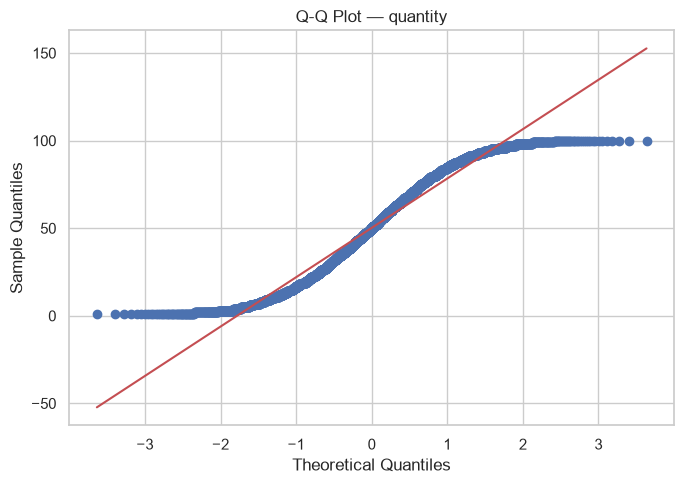

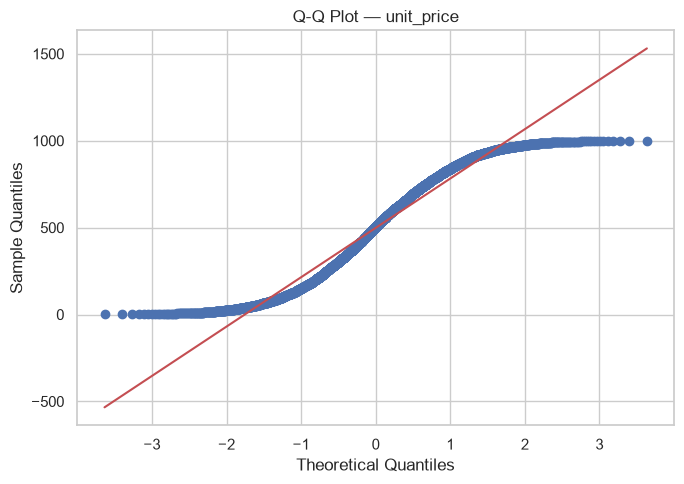

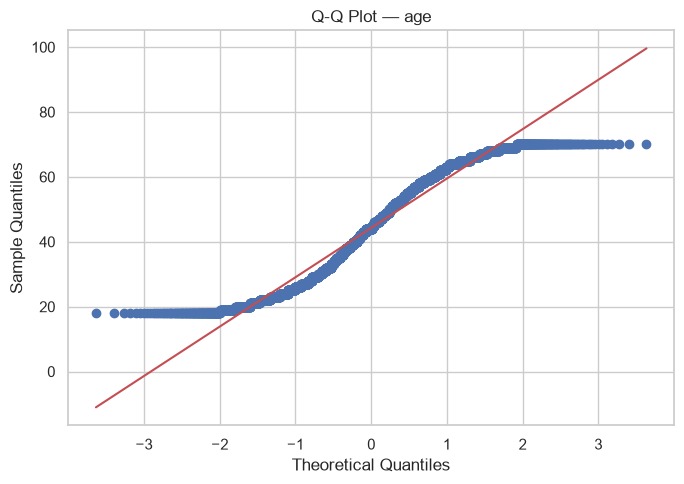

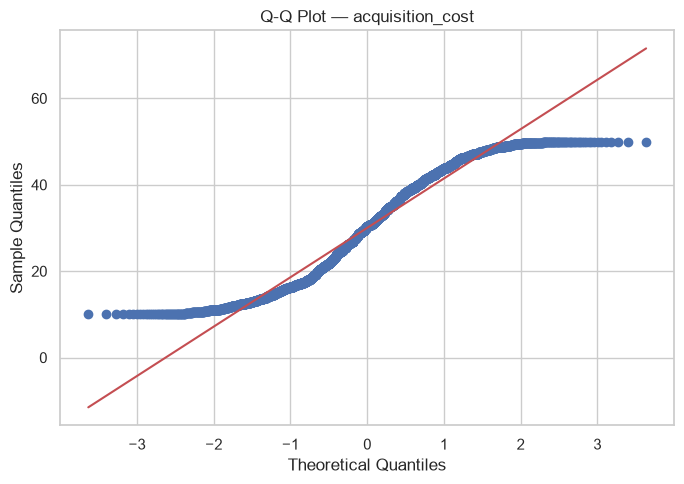

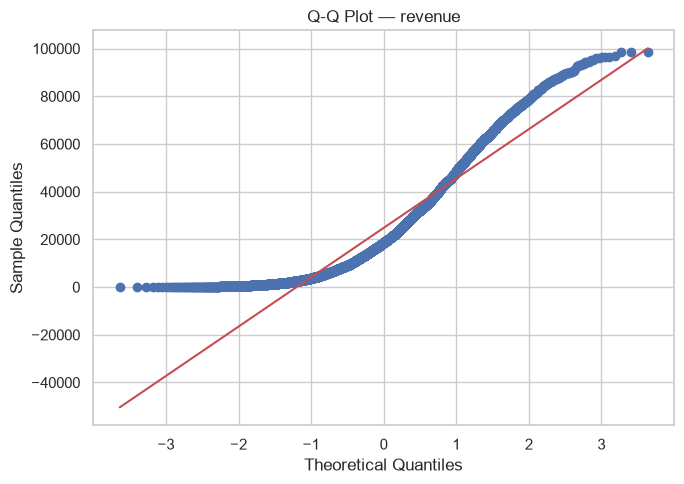

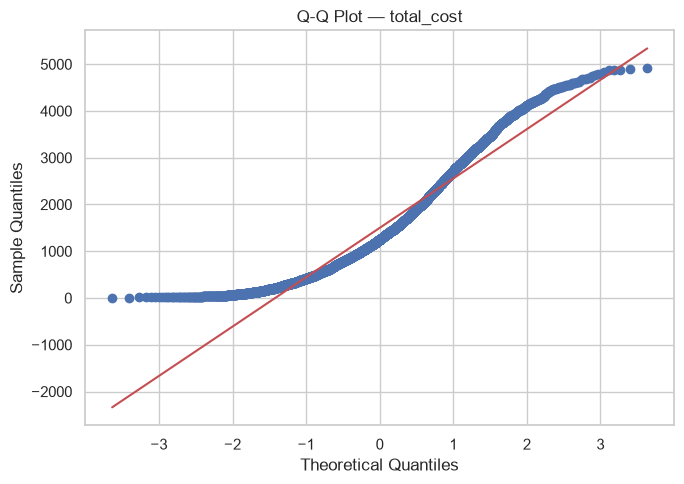

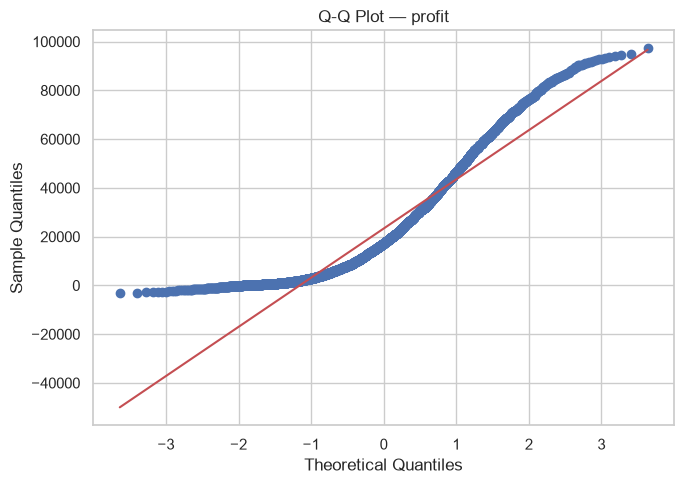

In [15]:
# Data visualization for normality assessment
from scipy.stats import probplot

for col in normality_cols:
    data = df_clean[col].dropna()
    if len(data) < 3:
        continue

    sample = data.sample(n=min(5000, len(data)), random_state=42)

    plt.figure(figsize=(7, 5))
    probplot(sample, dist="norm", plot=plt)
    plt.title(f"Q-Q Plot — {col}")
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Sample Quantiles")
    plt.tight_layout()
    plt.show()

In [16]:
# Data accuracy
accuracy_checks = {}

if {"revenue", "quantity", "unit_price"}.issubset(df_clean.columns):
    expected = df_clean["quantity"] * df_clean["unit_price"]
    accuracy_checks["revenue_formula_accuracy_pct"] = np.isclose(
        df_clean["revenue"], expected, equal_nan=True
    ).mean() * 100

if {"total_cost", "quantity", "acquisition_cost"}.issubset(df_clean.columns):
    expected = df_clean["quantity"] * df_clean["acquisition_cost"]
    accuracy_checks["total_cost_formula_accuracy_pct"] = np.isclose(
        df_clean["total_cost"], expected, equal_nan=True
    ).mean() * 100

if {"profit", "revenue", "total_cost"}.issubset(df_clean.columns):
    expected = df_clean["revenue"] - df_clean["total_cost"]
    accuracy_checks["profit_formula_accuracy_pct"] = np.isclose(
        df_clean["profit"], expected, equal_nan=True
    ).mean() * 100

if {"profit_margin_pct", "profit", "revenue"}.issubset(df_clean.columns):
    valid = df_clean["revenue"].ne(0)
    expected = (df_clean.loc[valid, "profit"] / df_clean.loc[valid, "revenue"]) * 100
    accuracy_checks["profit_margin_formula_accuracy_pct"] = np.isclose(
        df_clean.loc[valid, "profit_margin_pct"], expected, equal_nan=True
    ).mean() * 100

pd.DataFrame(accuracy_checks.items(), columns=["check", "accuracy_pct"])

,check,accuracy_pct
0,revenue_formula_accuracy_pct,100.0
1,total_cost_formula_accuracy_pct,100.0
2,profit_formula_accuracy_pct,100.0
3,profit_margin_formula_accuracy_pct,100.0


In [17]:
# Logical consistency checks
logic_checks = {}

rules = {
    "quantity_non_positive": ("quantity", lambda s: s <= 0),
    "unit_price_negative": ("unit_price", lambda s: s < 0),
    "acquisition_cost_negative": ("acquisition_cost", lambda s: s < 0),
    "age_outside_reasonable_range": ("age", lambda s: (s < 0) | (s > 120)),
    "revenue_negative": ("revenue", lambda s: s < 0),
}

for check_name, (col, condition) in rules.items():
    if col in df_clean.columns:
        logic_checks[check_name] = int(condition(df_clean[col].dropna()).sum())

pd.DataFrame(logic_checks.items(), columns=["validation_check", "invalid_rows"])

,validation_check,invalid_rows
0,quantity_non_positive,0
1,unit_price_negative,0
2,acquisition_cost_negative,0
3,age_outside_reasonable_range,0
4,revenue_negative,0


## 8) Exploratory Data Analysis

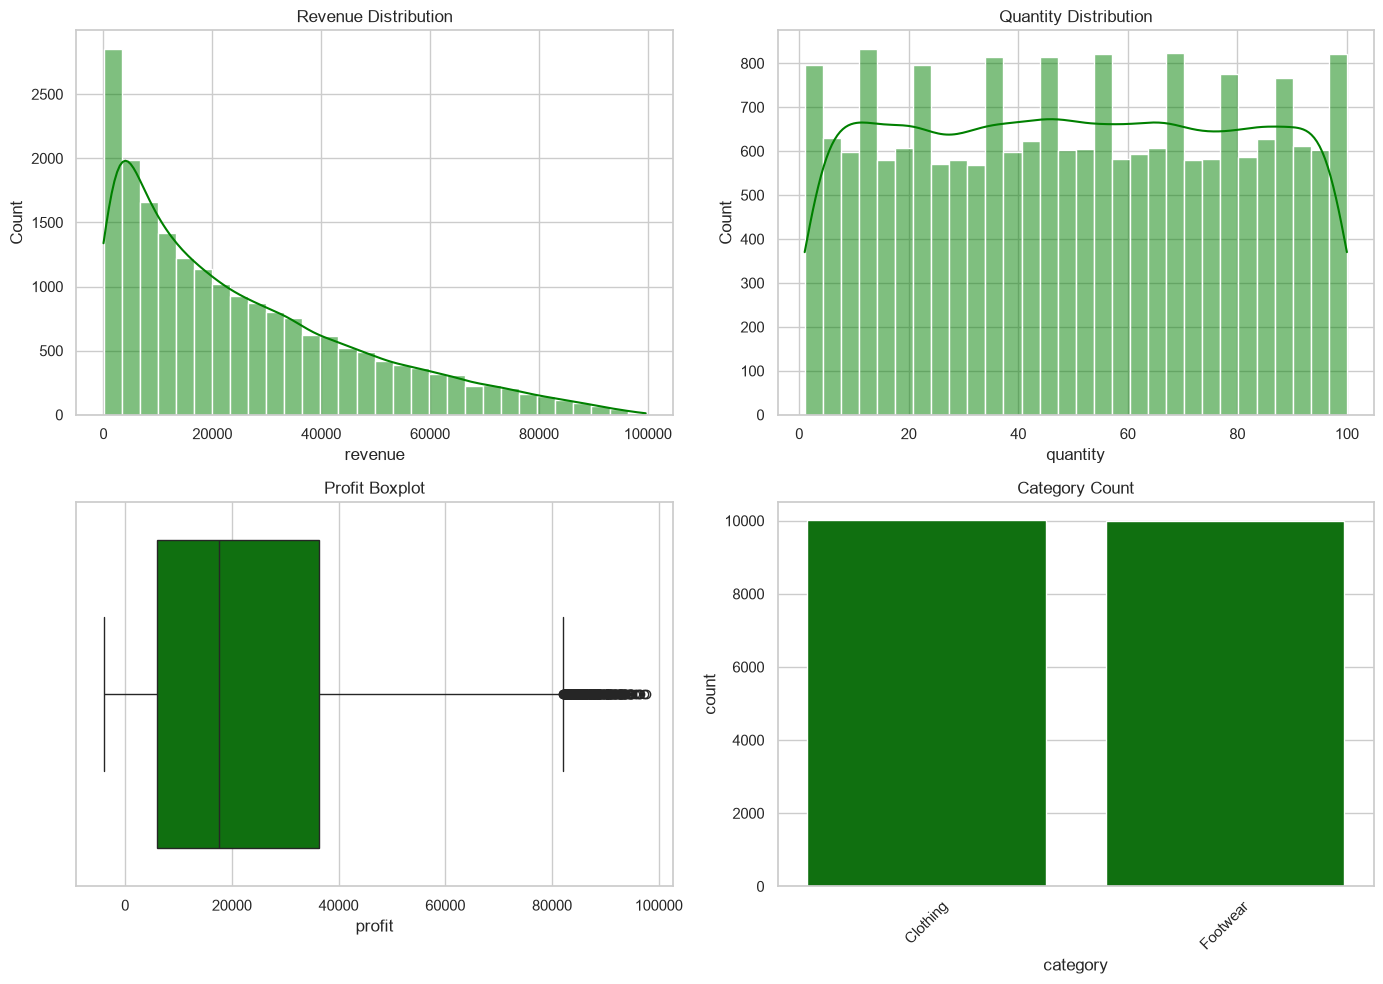

In [32]:
# Distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_clean["revenue"], bins=30, kde=True, color="green", ax=axes[0, 0])
axes[0, 0].set_title("Revenue Distribution")

sns.histplot(df_clean["quantity"], bins=30, kde=True, color="green", ax=axes[0, 1])
axes[0, 1].set_title("Quantity Distribution")

sns.boxplot(x=df_clean["profit"], color="green", ax=axes[1, 0])
axes[1, 0].set_title("Profit Boxplot")

sns.countplot(data=df_clean, x="category", color="green", ax=axes[1, 1])
axes[1, 1].set_title("Category Count")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

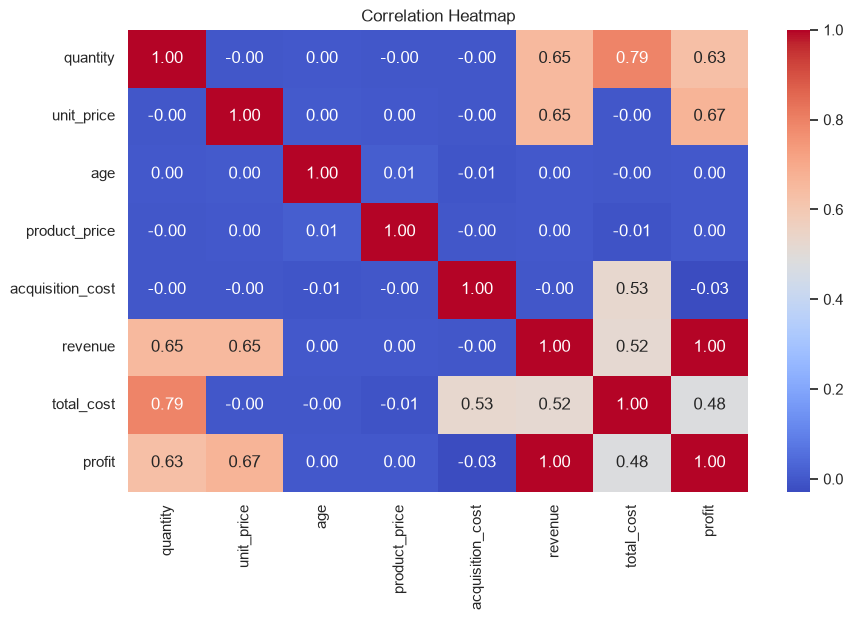

In [19]:
# Correlation heatmap
corr_cols = [c for c in ["quantity", "unit_price", "age", "product_price", "acquisition_cost", "revenue", "total_cost", "profit"] if c in df_clean.columns]
plt.figure(figsize=(10, 6))
sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 9) Factor Analysis

This section directly addresses the project requirement to identify factors associated with the target variable, **revenue**.

The analysis is divided into:

1. Numerical factor analysis using Spearman correlation.
2. Categorical factor analysis using group-level revenue metrics.
3. Statistical comparison across categories using Kruskal-Wallis.
4. Effect size using epsilon-squared (ε²), so statistical significance is not confused with practical importance.
5. A consolidated factor summary for stakeholder interpretation.

> **Important:** `revenue = quantity × unit_price`. Therefore, strong relationships between revenue, quantity, and unit price are partly mechanical by definition. They should be reported as revenue components, not treated as independent causal drivers.


Spearman correlation is used because the previous normality analysis may show that important numerical variables are not normally distributed. Spearman measures the strength and direction of a **monotonic association** without requiring normality.

Interpretation of |ρ|:
- 0.00–0.19: very weak
- 0.20–0.39: weak
- 0.40–0.59: moderate
- 0.60–0.79: strong
- 0.80–1.00: very strong

Correlation indicates association, **not causation**.


In [20]:
# Select numerical variables that actually exist in the cleaned dataset.
numeric_candidates = [
    "revenue",
    "quantity",
    "unit_price",
    "acquisition_cost",
    "age",
    "total_cost",
    "profit",
    "profit_margin_pct"
]

numeric_factor_cols = [
    col for col in numeric_candidates
    if col in df_clean.columns and pd.api.types.is_numeric_dtype(df_clean[col])
]

spearman_matrix = df_clean[numeric_factor_cols].corr(method="spearman")

spearman_matrix


,revenue,quantity,unit_price,acquisition_cost,age,total_cost,profit,profit_margin_pct
revenue,1.000000,0.665798,0.666476,-0.003068,0.005103,0.575215,0.997607,0.581152
quantity,0.665798,1.000000,-0.002212,-0.001585,0.000608,0.830329,0.626072,0.000479
unit_price,0.666476,-0.002212,1.000000,-0.002917,0.004734,-0.003621,0.694709,0.834081
acquisition_cost,-0.003068,-0.001585,-0.002917,1.000000,-0.006802,0.493253,-0.033189,-0.490972
age,0.005103,0.000608,0.004734,-0.006802,1.000000,-0.004230,0.005365,0.009878
total_cost,0.575215,0.830329,-0.003621,0.493253,-0.004230,1.000000,0.524044,-0.248990
profit,0.997607,0.626072,0.694709,-0.033189,0.005365,0.524044,1.000000,0.619209
profit_margin_pct,0.581152,0.000479,0.834081,-0.490972,0.009878,-0.248990,0.619209,1.000000


In [21]:
# Rank numerical variables by their association with revenue.
if "revenue" not in spearman_matrix.columns:
    raise ValueError("The target column 'revenue' is not available.")

revenue_spearman = (
    spearman_matrix["revenue"]
    .drop(labels=["revenue"])
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .rename("spearman_rho")
    .to_frame()
)

def correlation_strength(rho):
    x = abs(rho)
    if x < 0.20:
        return "Very Weak"
    elif x < 0.40:
        return "Weak"
    elif x < 0.60:
        return "Moderate"
    elif x < 0.80:
        return "Strong"
    return "Very Strong"

revenue_spearman["strength"] = revenue_spearman["spearman_rho"].apply(correlation_strength)
revenue_spearman["direction"] = np.where(
    revenue_spearman["spearman_rho"] >= 0, "Positive", "Negative"
)

revenue_spearman


,spearman_rho,strength,direction
profit,0.997607,Very Strong,Positive
unit_price,0.666476,Strong,Positive
quantity,0.665798,Strong,Positive
profit_margin_pct,0.581152,Moderate,Positive
total_cost,0.575215,Moderate,Positive
age,0.005103,Very Weak,Positive
acquisition_cost,-0.003068,Very Weak,Negative


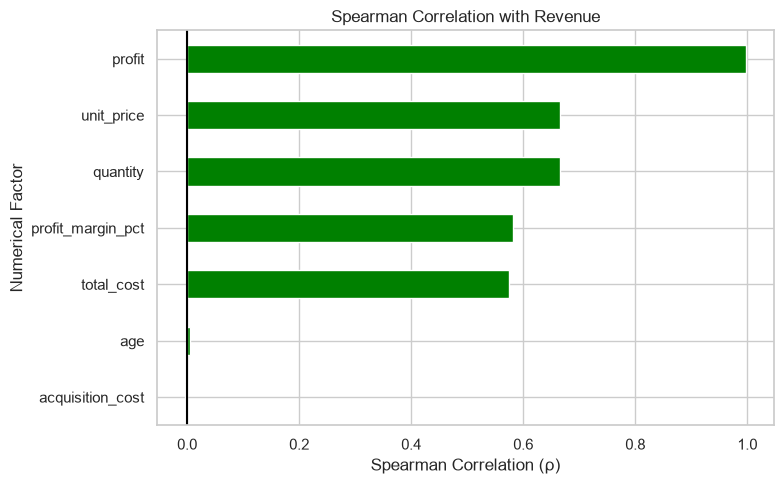

In [33]:
# Visualize numerical associations with the target.
plt.figure(figsize=(8, 5))
revenue_spearman.sort_values("spearman_rho")["spearman_rho"].plot(kind="barh", color="green")
plt.title("Spearman Correlation with Revenue")
plt.xlabel("Spearman Correlation (ρ)")
plt.ylabel("Numerical Factor")
plt.axvline(0, color="black")
plt.tight_layout()
plt.show()


`quantity` and `unit_price` are direct components of the revenue formula. `total_cost`, `profit`, and `profit_margin_pct` are also derived business metrics and may contain mathematical dependency on revenue.

For stakeholder-facing conclusions, place greater emphasis on **business characteristics** such as product category, customer segment, store/region, and time period rather than claiming that mathematically derived variables independently "cause" revenue.


For categorical variables, total revenue alone can be misleading because a category with more transactions will naturally tend to have more revenue.

Therefore, each factor is evaluated using:
- total revenue,
- average revenue per transaction,
- median revenue,
- number of transactions,
- revenue contribution percentage.


In [23]:
categorical_candidates = [
    "gender",
    "age_group",
    "category",
    "color",
    "size",
    "region",
    "store_city",
    "store_type",
    "store_name",
    "sale_month",
    "sale_quarter",
    "sale_weekday",
    "is_weekend"
]

categorical_factor_cols = [
    col for col in categorical_candidates
    if col in df_clean.columns
]

def categorical_revenue_summary(df, factor):
    result = (
        df.groupby(factor, dropna=False, observed=True)
        .agg(
            total_revenue=("revenue", "sum"),
            average_revenue=("revenue", "mean"),
            median_revenue=("revenue", "median"),
            transactions=("revenue", "size")
        )
        .reset_index()
    )

    total = result["total_revenue"].sum()
    result["revenue_contribution_pct"] = np.where(
        total != 0,
        result["total_revenue"] / total * 100,
        np.nan
    )

    return result.sort_values("total_revenue", ascending=False)

factor_summaries = {
    factor: categorical_revenue_summary(df_clean, factor)
    for factor in categorical_factor_cols
}

print("Categorical factors available:")
print(categorical_factor_cols)


Categorical factors available:
['gender', 'age_group', 'category', 'color', 'size', 'region', 'store_city', 'store_type', 'store_name', 'sale_month', 'sale_quarter', 'sale_weekday', 'is_weekend']


In [24]:
# Display compact summaries for each categorical factor.
for factor, summary in factor_summaries.items():
    print(f"\n===== Revenue by {factor} =====")
    display(summary.head(15))



===== Revenue by gender =====


,gender,total_revenue,average_revenue,median_revenue,transactions,revenue_contribution_pct
1,Male,2.630939e+08,25037.485305,18843.945,10508,52.081377
0,Female,2.420654e+08,25502.038978,19296.080,9492,47.918623



===== Revenue by age_group =====


,age_group,total_revenue,average_revenue,median_revenue,transactions,revenue_contribution_pct
4,55-64,99879924.23,25146.003079,19087.725,3972,19.771968
3,45-54,94174938.10,25604.931512,19775.640,3678,18.642624
1,25-34,92966442.44,25146.454542,18431.520,3697,18.403393
2,35-44,89335779.56,25052.097465,19132.110,3566,17.684677
0,18-24,66246540.75,25304.255443,19176.180,2618,13.113991
5,65+,62555624.48,25336.421418,19163.100,2469,12.383347



===== Revenue by category =====


...

,sale_quarter,total_revenue,average_revenue,median_revenue,transactions,revenue_contribution_pct
0,Q1,1.294465e+08,25889.298338,19349.250,5000,25.624888
2,Q3,1.287553e+08,25330.565825,19387.170,5083,25.488055
3,Q4,1.234880e+08,24982.400957,18590.360,4943,24.445362
1,Q2,1.234695e+08,24822.976246,18820.725,4974,24.441695



===== Revenue by sale_weekday =====


,sale_weekday,total_revenue,average_revenue,median_revenue,transactions,revenue_contribution_pct
0,Friday,75098780.93,25483.128921,19570.800,2947,14.866358
6,Wednesday,74350228.11,25735.627591,20198.100,2889,14.718176
2,Saturday,73946719.95,25595.957061,18977.280,2889,14.638299
5,Tuesday,71746746.49,25298.570695,18997.040,2836,14.202798
4,Thursday,70291683.60,25239.383698,19208.640,2785,13.914757
3,Sunday,70140792.65,24559.101068,18231.235,2856,13.884887
1,Monday,69584297.83,24869.298724,18442.425,2798,13.774725



===== Revenue by is_weekend =====


,is_weekend,total_revenue,average_revenue,median_revenue,transactions,revenue_contribution_pct
0,False,3.610717e+08,25329.479969,19260.40,14255,71.476814
1,True,1.440875e+08,25080.506980,18482.82,5745,28.523186


Because transaction-level revenue may not be normally distributed, the **Kruskal-Wallis H test** is used to test whether the revenue distributions differ across groups.

**H0:** revenue distributions are equal across groups.  
**H1:** at least one group differs.

A small p-value indicates statistical evidence of differences, but with a large dataset even small differences can become statistically significant. Therefore, an **effect size** is calculated as well.


In [25]:
from scipy.stats import kruskal

def epsilon_squared_kruskal(H, n, k):
    # Common epsilon-squared approximation for Kruskal-Wallis.
    if n <= k:
        return np.nan
    return max(0, (H - k + 1) / (n - k))

kruskal_results = []

# Avoid extremely high-cardinality identifiers/names in omnibus tests.
test_candidates = [
    "gender",
    "age_group",
    "category",
    "color",
    "size",
    "region",
    "store_type",
    "sale_month",
    "sale_quarter",
    "sale_weekday",
    "is_weekend"
]

for factor in test_candidates:
    if factor not in df_clean.columns:
        continue

    subset = df_clean[[factor, "revenue"]].dropna()
    groups = [
        group["revenue"].values
        for _, group in subset.groupby(factor, observed=True)
        if len(group) >= 2
    ]

    k = len(groups)
    n = sum(len(g) for g in groups)

    if k < 2:
        continue

    H, p_value = kruskal(*groups)
    eps2 = epsilon_squared_kruskal(H, n, k)

    kruskal_results.append({
        "factor": factor,
        "groups": k,
        "n": n,
        "kruskal_H": H,
        "p_value": p_value,
        "epsilon_squared": eps2,
        "statistically_significant_0.05": p_value < 0.05
    })

kruskal_results = (
    pd.DataFrame(kruskal_results)
    .sort_values("epsilon_squared", ascending=False)
    .reset_index(drop=True)
)

kruskal_results


,factor,groups,n,kruskal_H,p_value,epsilon_squared,statistically_significant_0.05
0,sale_quarter,4,20000,6.024229e+00,0.110437,0.000151,False
1,region,3,20000,4.721735e+00,0.094338,0.000136,False
2,sale_weekday,7,20000,6.736926e+00,0.345863,0.000037,False
3,gender,2,20000,1.730694e+00,0.188322,0.000037,False
4,age_group,6,20000,1.137664e+00,0.950716,0.000000,False
5,category,2,20000,3.528174e-01,0.552523,0.000000,False
6,color,10,20000,6.544881e+00,0.684386,0.000000,False
7,size,17,20000,1.033767e+01,0.848410,0.000000,False
8,store_type,2,20000,1.016597e-07,0.999746,0.000000,False
9,sale_month,12,20000,1.001756e+01,0.528809,0.000000,False


For epsilon-squared (ε²), use these values only as practical rules of thumb:

- < 0.01: negligible
- 0.01–0.06: small
- 0.06–0.14: moderate
- ≥ 0.14: large

The effect size is especially important here because a very large number of transactions can produce a small p-value even when the actual business difference is minor.


In [26]:
def effect_size_label(x):
    if pd.isna(x):
        return "N/A"
    if x < 0.01:
        return "Negligible"
    elif x < 0.06:
        return "Small"
    elif x < 0.14:
        return "Moderate"
    return "Large"

if not kruskal_results.empty:
    kruskal_results["effect_size"] = (
        kruskal_results["epsilon_squared"].apply(effect_size_label)
    )

kruskal_results


,factor,groups,n,kruskal_H,p_value,epsilon_squared,statistically_significant_0.05,effect_size
0,sale_quarter,4,20000,6.024229e+00,0.110437,0.000151,False,Negligible
1,region,3,20000,4.721735e+00,0.094338,0.000136,False,Negligible
2,sale_weekday,7,20000,6.736926e+00,0.345863,0.000037,False,Negligible
3,gender,2,20000,1.730694e+00,0.188322,0.000037,False,Negligible
4,age_group,6,20000,1.137664e+00,0.950716,0.000000,False,Negligible
5,category,2,20000,3.528174e-01,0.552523,0.000000,False,Negligible
6,color,10,20000,6.544881e+00,0.684386,0.000000,False,Negligible
7,size,17,20000,1.033767e+01,0.848410,0.000000,False,Negligible
8,store_type,2,20000,1.016597e-07,0.999746,0.000000,False,Negligible
9,sale_month,12,20000,1.001756e+01,0.528809,0.000000,False,Negligible


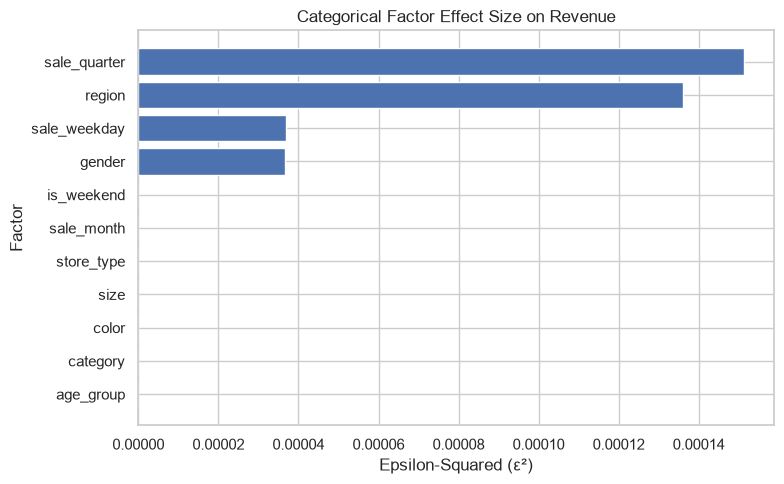

In [27]:
if not kruskal_results.empty:
    plot_df = kruskal_results.sort_values("epsilon_squared")

    plt.figure(figsize=(8, 5))
    plt.barh(plot_df["factor"], plot_df["epsilon_squared"])
    plt.title("Categorical Factor Effect Size on Revenue")
    plt.xlabel("Epsilon-Squared (ε²)")
    plt.ylabel("Factor")
    plt.tight_layout()
    plt.show()


The following tables focus on factors that stakeholders can potentially act on. They are preferable to relying only on correlations between revenue and variables used directly in the revenue formula.


In [28]:
business_focus = [
    "category",
    "age_group",
    "gender",
    "region",
    "store_type",
    "sale_quarter",
    "sale_weekday",
    "is_weekend"
]

for factor in business_focus:
    if factor in factor_summaries:
        print(f"\n===== BUSINESS FACTOR: {factor} =====")
        display(
            factor_summaries[factor][
                [
                    factor,
                    "total_revenue",
                    "average_revenue",
                    "median_revenue",
                    "transactions",
                    "revenue_contribution_pct"
                ]
            ].head(10)
        )



===== BUSINESS FACTOR: category =====


,category,total_revenue,average_revenue,median_revenue,transactions,revenue_contribution_pct
1,Footwear,2.537537e+08,25403.312499,19191.00,9989,50.232415
0,Clothing,2.514056e+08,25112.931876,19005.42,10011,49.767585



===== BUSINESS FACTOR: age_group =====


,age_group,total_revenue,average_revenue,median_revenue,transactions,revenue_contribution_pct
4,55-64,99879924.23,25146.003079,19087.725,3972,19.771968
3,45-54,94174938.10,25604.931512,19775.640,3678,18.642624
1,25-34,92966442.44,25146.454542,18431.520,3697,18.403393
2,35-44,89335779.56,25052.097465,19132.110,3566,17.684677
0,18-24,66246540.75,25304.255443,19176.180,2618,13.113991
5,65+,62555624.48,25336.421418,19163.100,2469,12.383347



===== BUSINESS FACTOR: gender =====


...

,sale_quarter,total_revenue,average_revenue,median_revenue,transactions,revenue_contribution_pct
0,Q1,1.294465e+08,25889.298338,19349.250,5000,25.624888
2,Q3,1.287553e+08,25330.565825,19387.170,5083,25.488055
3,Q4,1.234880e+08,24982.400957,18590.360,4943,24.445362
1,Q2,1.234695e+08,24822.976246,18820.725,4974,24.441695



===== BUSINESS FACTOR: sale_weekday =====


,sale_weekday,total_revenue,average_revenue,median_revenue,transactions,revenue_contribution_pct
0,Friday,75098780.93,25483.128921,19570.800,2947,14.866358
6,Wednesday,74350228.11,25735.627591,20198.100,2889,14.718176
2,Saturday,73946719.95,25595.957061,18977.280,2889,14.638299
5,Tuesday,71746746.49,25298.570695,18997.040,2836,14.202798
4,Thursday,70291683.60,25239.383698,19208.640,2785,13.914757
3,Sunday,70140792.65,24559.101068,18231.235,2856,13.884887
1,Monday,69584297.83,24869.298724,18442.425,2798,13.774725



===== BUSINESS FACTOR: is_weekend =====


,is_weekend,total_revenue,average_revenue,median_revenue,transactions,revenue_contribution_pct
0,False,3.610717e+08,25329.479969,19260.40,14255,71.476814
1,True,1.440875e+08,25080.506980,18482.82,5745,28.523186


In [29]:
# Build a concise statistical ranking of categorical factors.
categorical_factor_ranking = pd.DataFrame()

if not kruskal_results.empty:
    categorical_factor_ranking = kruskal_results[
        [
            "factor",
            "p_value",
            "epsilon_squared",
            "effect_size",
            "statistically_significant_0.05"
        ]
    ].copy()

categorical_factor_ranking


,factor,p_value,epsilon_squared,effect_size,statistically_significant_0.05
0,sale_quarter,0.110437,0.000151,Negligible,False
1,region,0.094338,0.000136,Negligible,False
2,sale_weekday,0.345863,0.000037,Negligible,False
3,gender,0.188322,0.000037,Negligible,False
4,age_group,0.950716,0.000000,Negligible,False
5,category,0.552523,0.000000,Negligible,False
6,color,0.684386,0.000000,Negligible,False
7,size,0.848410,0.000000,Negligible,False
8,store_type,0.999746,0.000000,Negligible,False
9,sale_month,0.528809,0.000000,Negligible,False


## 9) Save cleaned outputs

In [31]:
output_csv = "sales_analysis_translated_cleaned.csv"
df_clean.to_csv(output_csv, index=False)
print(f"Saved: {output_csv}")

Saved: sales_analysis_translated_cleaned.csv
